# Lab - Network Intrusion Detection (Random Forest Classification)

## The Data

This dataset (NSL-KDD, an improved version of the classic KDD Cup 99 dataset) will be used to
answer the question of whether or not a given network connection record is malicious traffic.

* Features / Independent Variables (41 total, a few highlighted below)
    * duration - Length of the connection in seconds
    * protocol_type - Connection protocol (tcp, udp, icmp)
    * service - Destination network service (http, ftp, telnet, etc.)
    * flag - Status of the connection (normal or error)
    * src_bytes / dst_bytes - Bytes sent from source to destination and vice versa
    * count - Number of connections to the same host in the past two seconds
    * serror_rate / srv_serror_rate - % of connections with "SYN" errors
    * dst_host_srv_count - Number of connections to the same service on the destination host
    * ... (37 more numeric/categorical traffic features)
* Target / Label / Dependent Variable
    * label - The specific attack signature (e.g. neptune, smurf, satan) or "normal"
    * binary_label - 0 for normal traffic, 1 for an attack (engineered below)

## Importing the libraries and data

### Importing the libraries

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

# Third party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports from SkLearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# Shared column names and model pipelines (also used by train.py and detect.py)
from nids import COLUMNS, FEATURES, build_random_forest, build_svm, load_kdd

### Importing the dataset

The NSL-KDD files don't ship with a header row, so we attach the official column names.

In [2]:
df_traffic = pd.read_csv('KDD.txt', names=COLUMNS)
df_traffic.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [3]:
df_traffic.shape

(125973, 43)

## Initial data preprocessing

### Check for missing values

In [4]:
df_traffic.isnull().sum().sum()

np.int64(0)

There are no missing values, so no imputation is needed.

### Engineering the binary label

The raw `label` column has 20+ specific attack signatures (neptune, smurf, satan, ...). Since the
goal is to detect *malicious traffic* generally, we collapse this into a binary label.

In [5]:
df_traffic['binary_label'] = (df_traffic['label'] != 'normal').astype(int)
df_traffic['label'].value_counts().head(10)

label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

In [6]:
df_traffic.drop(columns=['label', 'difficulty'], inplace=True)
df_traffic.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


## Exploratory Data Analysis

### Class balance of the dependent variable

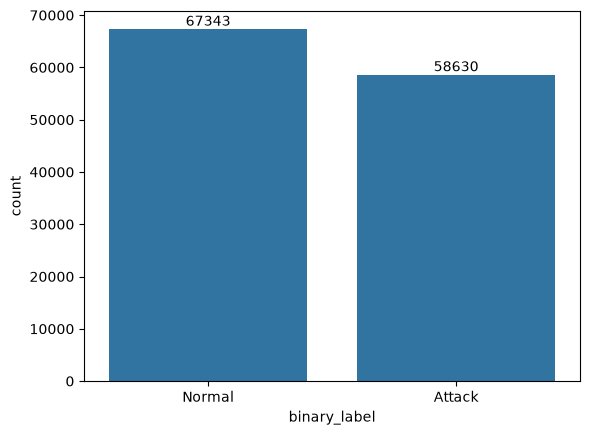

In [7]:
ax = sns.countplot(x='binary_label', data=df_traffic)
ax.set_xticklabels(['Normal', 'Attack'])
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Summary statistics of the numeric features

In [8]:
df_traffic.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,0.465417
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,0.498805
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,1.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Histograms of a few key independent variables

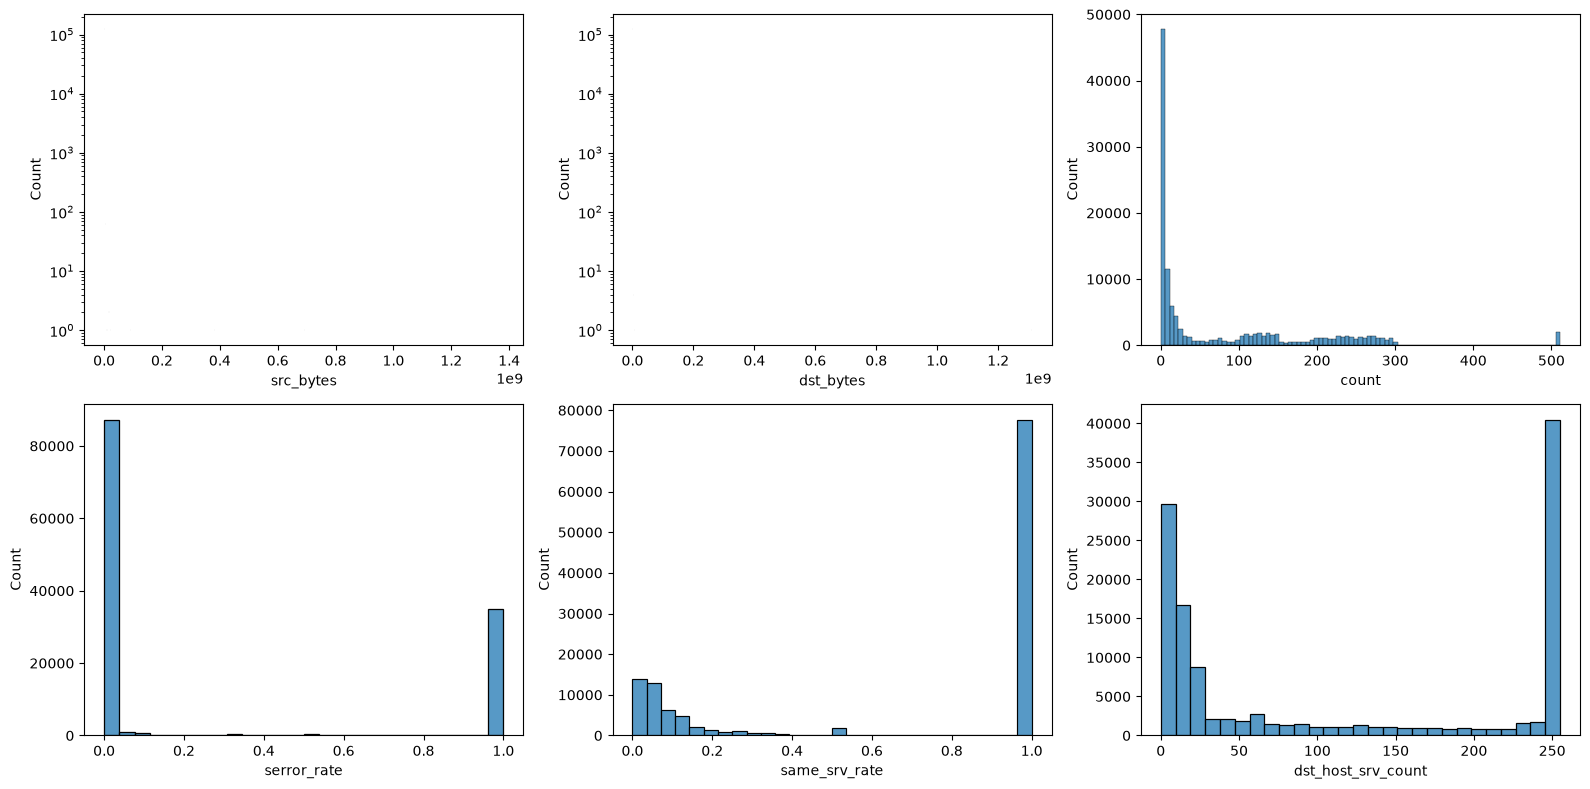

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
sns.histplot(ax=axes[0][0], x='src_bytes', data=df_traffic, log_scale=(False, True))
sns.histplot(ax=axes[0][1], x='dst_bytes', data=df_traffic, log_scale=(False, True))
sns.histplot(ax=axes[0][2], x='count', data=df_traffic)
sns.histplot(ax=axes[1][0], x='serror_rate', data=df_traffic)
sns.histplot(ax=axes[1][1], x='same_srv_rate', data=df_traffic)
sns.histplot(ax=axes[1][2], x='dst_host_srv_count', data=df_traffic)
plt.tight_layout()
plt.show()

### Box-and-whisker plots for a few independent variables vs. the dependent variable

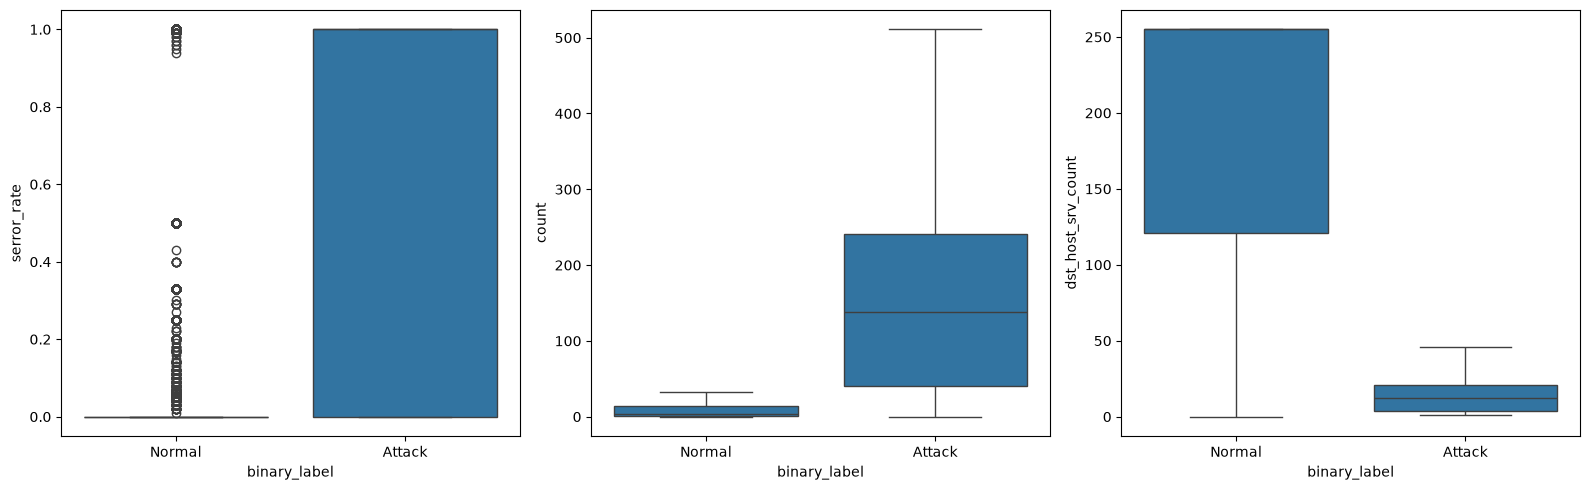

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
sns.boxplot(ax=axes[0], x='binary_label', y='serror_rate', data=df_traffic)
sns.boxplot(ax=axes[1], x='binary_label', y='count', data=df_traffic, showfliers=False)
sns.boxplot(ax=axes[2], x='binary_label', y='dst_host_srv_count', data=df_traffic, showfliers=False)
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[1].set_xticklabels(['Normal', 'Attack'])
axes[2].set_xticklabels(['Normal', 'Attack'])
plt.tight_layout()
plt.show()

### A heatmap of the Pearson's correlation coefficients (top correlated features only)

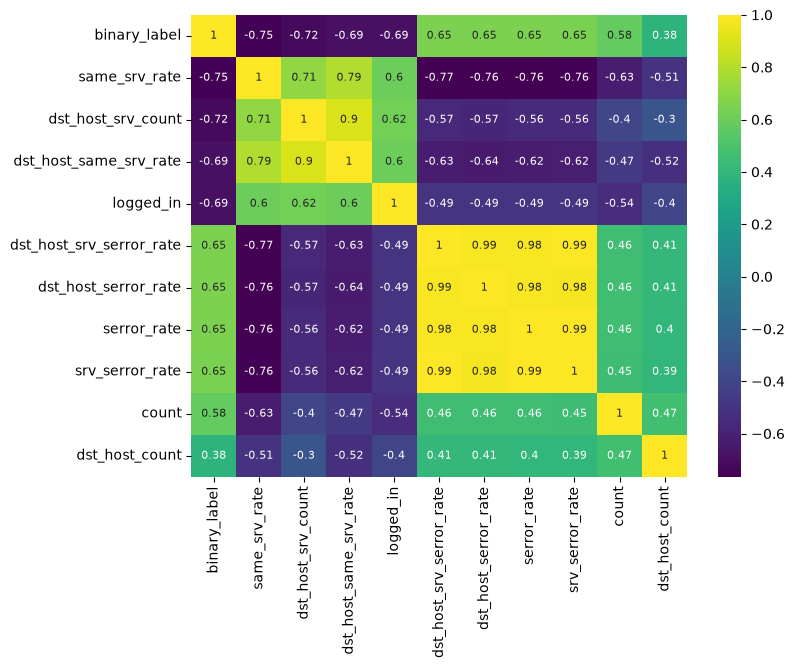

In [11]:
top_feats = df_traffic.corr(numeric_only=True)['binary_label'].abs().sort_values(ascending=False).head(11).index
plt.figure(dpi=100, figsize=(8, 6))
sns.heatmap(df_traffic[top_feats].corr(), annot=True, annot_kws={'fontsize': 8}, cmap='viridis')
plt.show()

### EDA Summary

* The classes are reasonably balanced: about 53% normal traffic vs. 47% attack traffic, so accuracy
  is a meaningful metric here (no heavy class-imbalance correction needed).
* `src_bytes` and `dst_bytes` are extremely right-skewed (log scale needed just to see the shape) -
  most connections move very little data, with a long tail of large transfers.
* The `serror_rate`, `count`, and `dst_host_srv_count` features show clearly different distributions
  for normal vs. attack traffic, which is expected: many attacks (e.g. port scans, SYN floods) show up
  as a burst of connections with high error rates to the same host in a short window.
* The strongest correlated features with the label are the error-rate features
  (`serror_rate`, `srv_serror_rate`, `dst_host_serror_rate`), which lines up with the intuition
  that failed/incomplete connection attempts are a strong signature of scanning and flooding attacks.

## Data Preprocessing

### Encoding and scaling as a reusable pipeline

The categorical features (`protocol_type`, `service`, `flag`) and the numeric features need different
preprocessing depending on the model, so each model is a scikit-learn `Pipeline` defined in `nids.py`:

* **Random Forest** - the categoricals are ordinal-encoded. Trees split on individual values, so
  they don't assume ordinal distance, and the numeric features need no scaling.
* **SVM** - an RBF SVM is distance-based, so the categoricals are one-hot encoded, and the heavily
  skewed numeric features are log-scaled (`log1p`) before standardizing.

Bundling preprocessing into the pipeline means the encoders are fit once on the training data and
reused unchanged for the test split, the official holdout file, and the real-time detector.
Categories the model has never seen (e.g. a new `service`) are handled instead of raising an error.

### Making the dependent and independent variables

In [12]:
X = df_traffic[FEATURES]
y = df_traffic['binary_label']

### Splitting the data into training and testing sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((100778, 41), (25195, 41))

## Training and Testing the Models

### Training the Random Forest classifier

In [14]:
rf_model = build_random_forest()
start = time.perf_counter()
rf_model.fit(X_train, y_train)
print(f'Trained in {time.perf_counter() - start:.1f}s')

Trained in 2.0s


### Predicting the testing set

In [15]:
y_pred = rf_model.predict(X_test)

### Testing the model with a confusion matrix

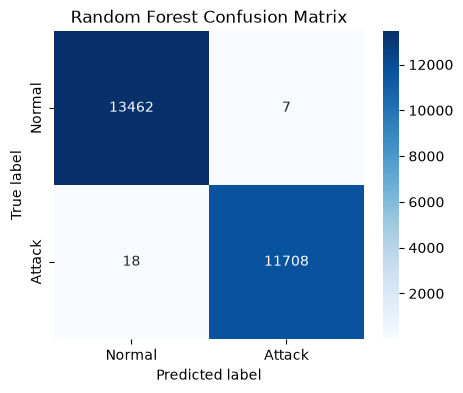

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Testing the model with its accuracy score

In [17]:
print(f'Our model has an accuracy score of {accuracy_score(y_test, y_pred) * 100:.2f}%')

Our model has an accuracy score of 99.90%


### How well does the model fit the data?

The model fits the data extremely well, correctly classifying the vast majority of connections
with very few false positives or false negatives.

### Which features mattered most?

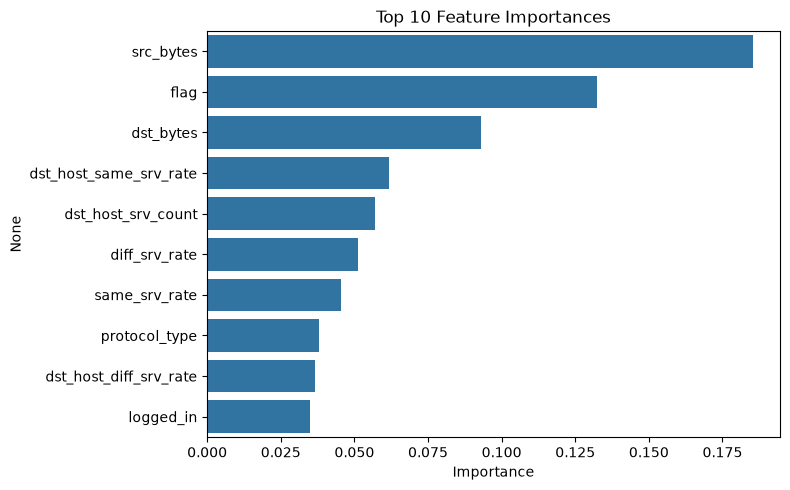

In [18]:
names = [n.split('__')[-1] for n in rf_model[0].get_feature_names_out()]
importances = pd.Series(rf_model[-1].feature_importances_, index=names).sort_values(ascending=False)
plt.figure(figsize=(8, 5), dpi=100)
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

The top features are dominated by traffic volume (`src_bytes`, `dst_bytes`) and the
same-service rates (`same_srv_rate`, `dst_host_same_srv_rate`). This matches the EDA, where those
features showed the clearest separation between normal and attack traffic.

### Training the SVM classifier

For comparison, an RBF-kernel Support Vector Machine is trained on the same split. SVM training
scales worse than linear with the number of rows, so this cell takes noticeably longer than the
Random Forest.

In [19]:
svm_model = build_svm()
start = time.perf_counter()
svm_model.fit(X_train, y_train)
print(f'Trained in {time.perf_counter() - start:.1f}s')

y_pred_svm = svm_model.predict(X_test)
print(f'SVM accuracy score: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%')

Trained in 66.9s


SVM accuracy score: 99.78%


### Comparing the models

In [20]:
def scores(y_true, y_pred):
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {'accuracy': accuracy_score(y_true, y_pred), 'precision': prec, 'recall': rec, 'f1': f1}

comparison = pd.DataFrame({'Random Forest': scores(y_test, y_pred),
                           'SVM': scores(y_test, y_pred_svm)}).T
comparison.style.format('{:.2%}')

,accuracy,precision,recall,f1
Random Forest,99.90%,99.94%,99.85%,99.89%
SVM,99.78%,99.85%,99.67%,99.76%


## Real-time inference latency

To use the model as a live detector (see `detect.py`), what matters is how quickly a new connection
can be classified. Predicting one record at a time pays scikit-learn's per-call overhead on every
connection, so the detector groups incoming records into small micro-batches instead. The cell
below compares the per-record latency of both approaches.

In [21]:
# Like detect.py, predict single-threaded: thread startup costs more than it saves on small batches
rf_model[-1].n_jobs = 1
sample = X_test.iloc[:500]

def per_record_us(model, batch_size):
    start = time.perf_counter()
    for i in range(0, len(sample), batch_size):
        model.predict(sample.iloc[i:i + batch_size])
    return (time.perf_counter() - start) / len(sample) * 1e6

latency = pd.DataFrame({
    name: {f'batch of {b}': per_record_us(model, b) for b in [1, 32, 256]}
    for name, model in [('Random Forest', rf_model), ('SVM', svm_model)]
})
latency.style.format('{:,.1f} us')

,Random Forest,SVM
batch of 1,"10,717.0 us","5,304.4 us"
batch of 32,329.6 us,615.8 us
batch of 256,46.4 us,135.1 us


## A note on generalization: testing against unseen attack types

The NSL-KDD dataset ships with a separate official test file (`KDDTest+.txt`, here `KDDTest.txt`)
that intentionally includes attack types that never appear in the training file. It tests whether a
model has learned generalizable attack *patterns* rather than memorizing specific attack signatures.

Because the encoders live inside each pipeline, the holdout file goes through exactly the same
preprocessing the models were trained with.

In [22]:
_, _, train_labels = load_kdd('KDD.txt')
X_holdout, y_holdout, holdout_labels = load_kdd('KDDTest.txt')

new_attack_types = set(holdout_labels.unique()) - set(train_labels.unique())
print(f'Attack types in the holdout file that never appeared in training: {len(new_attack_types)}')

holdout = pd.DataFrame({'Random Forest': scores(y_holdout, rf_model.predict(X_holdout)),
                        'SVM': scores(y_holdout, svm_model.predict(X_holdout))}).T
holdout.style.format('{:.2%}')

Attack types in the holdout file that never appeared in training: 17


,accuracy,precision,recall,f1
Random Forest,77.21%,96.79%,62.03%,75.60%
SVM,76.99%,92.13%,65.14%,76.32%


### Why is the holdout accuracy so much lower?

* On a random 80/20 split of the *same* file, both models score in the high 90s% because the train
  and test rows are drawn from the same attack signatures - the models have effectively "seen" every
  attack type they're being tested on.
* On the official holdout file, 17 attack signatures never appear during training. The models can
  only catch these novel attacks if the underlying traffic *pattern* (e.g. high `serror_rate`,
  unusual `same_srv_rate`) resembles something they have learned.
* Precision stays high while recall drops: when the models flag something it's almost always an
  attack, but they miss many of the novel attacks entirely.
* A single accuracy number from a same-distribution split overstates real-world performance. A
  security tool's value depends heavily on how well it generalizes to attacks it has never seen,
  which is exactly what this holdout test is designed to reveal.

## Conclusion

* On a standard 80/20 split, both models detect attacks with high accuracy: the Random Forest is
  near-perfect, and the SVM is close behind.
* The Random Forest also trains far faster, and at the detector's batch size of 256 it classifies
  each connection roughly 3x faster than the SVM, which makes it the default model for the
  real-time detector (`detect.py`). Micro-batching cuts per-record latency by more than 100x
  compared with classifying one connection at a time.
* The most informative features were `src_bytes`, `dst_bytes`, `same_srv_rate`, and the
  error-rate family of features - all of which have a clear security interpretation (traffic volume
  and connection-failure patterns).
* Accuracy alone is not the full picture: testing against the official holdout file (with unseen
  attack types) shows a large drop, driven by missed novel attacks (low recall). That is a much more
  honest measure of how a network intrusion detector would perform against real-world attacks.